In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from datetime import datetime, timedelta

import yfinance as yf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

6(a): Download Data & Plot

In [10]:
end   = datetime.today()
start = end - timedelta(days=365 * 20)

df = yf.Ticker('^NSEI').history(start=start.strftime('%Y-%m-%d'),
                                end=end.strftime('%Y-%m-%d'))['Close'].dropna()
df.index = pd.to_datetime(df.index).tz_localize(None)

test  = df.iloc[-5:]
train = df.iloc[:-5]

print(f'Full : {df.index[0].date()} -> {df.index[-1].date()}  ({len(df)} obs)')
print(f'Train: {train.index[0].date()} -> {train.index[-1].date()}  ({len(train)} obs)')
print(f'Test : {test.index[0].date()}  -> {test.index[-1].date()}   ({len(test)} obs)')
print(f'\nDescriptive Stats (Training):\n{train.describe().round(2)}')

Full : 2007-09-17 -> 2026-03-27  (4545 obs)
Train: 2007-09-17 -> 2026-03-19  (4540 obs)
Test : 2026-03-20  -> 2026-03-27   (5 obs)

Descriptive Stats (Training):
count     4540.00
mean     11081.28
std       6482.98
min       2524.20
25%       5695.15
50%       8764.67
75%      15834.60
max      26328.55
Name: Close, dtype: float64


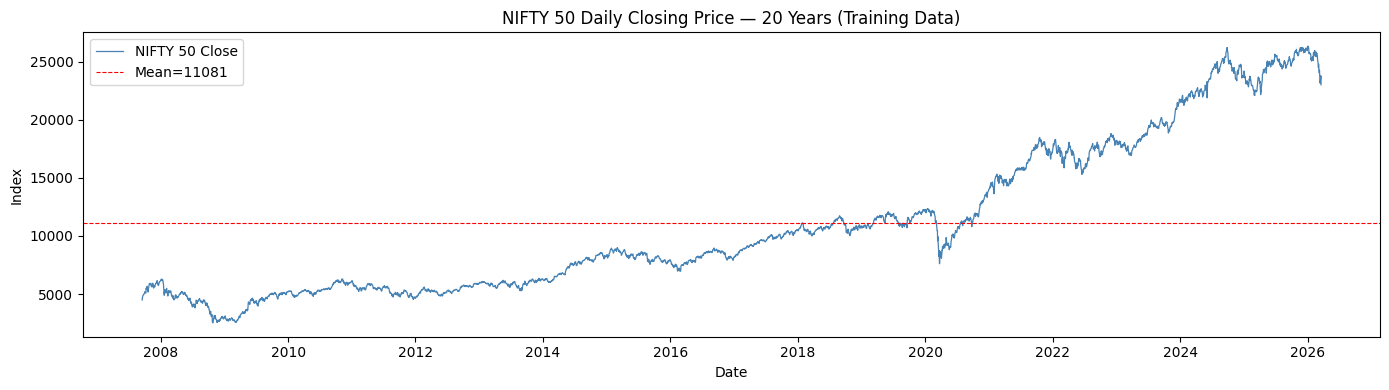

In [11]:
plt.figure(figsize=(14, 4))
plt.plot(train, color='steelblue', lw=0.9, label='NIFTY 50 Close')
plt.axhline(train.mean(), color='red', ls='--', lw=0.8, label=f'Mean={train.mean():.0f}')
plt.title('NIFTY 50 Daily Closing Price — 20 Years (Training Data)')
plt.xlabel('Date') 
plt.ylabel('Index') 
plt.legend() 
plt.tight_layout() 
plt.show()

6(b): ACF & PACF of Original & Differenced Series

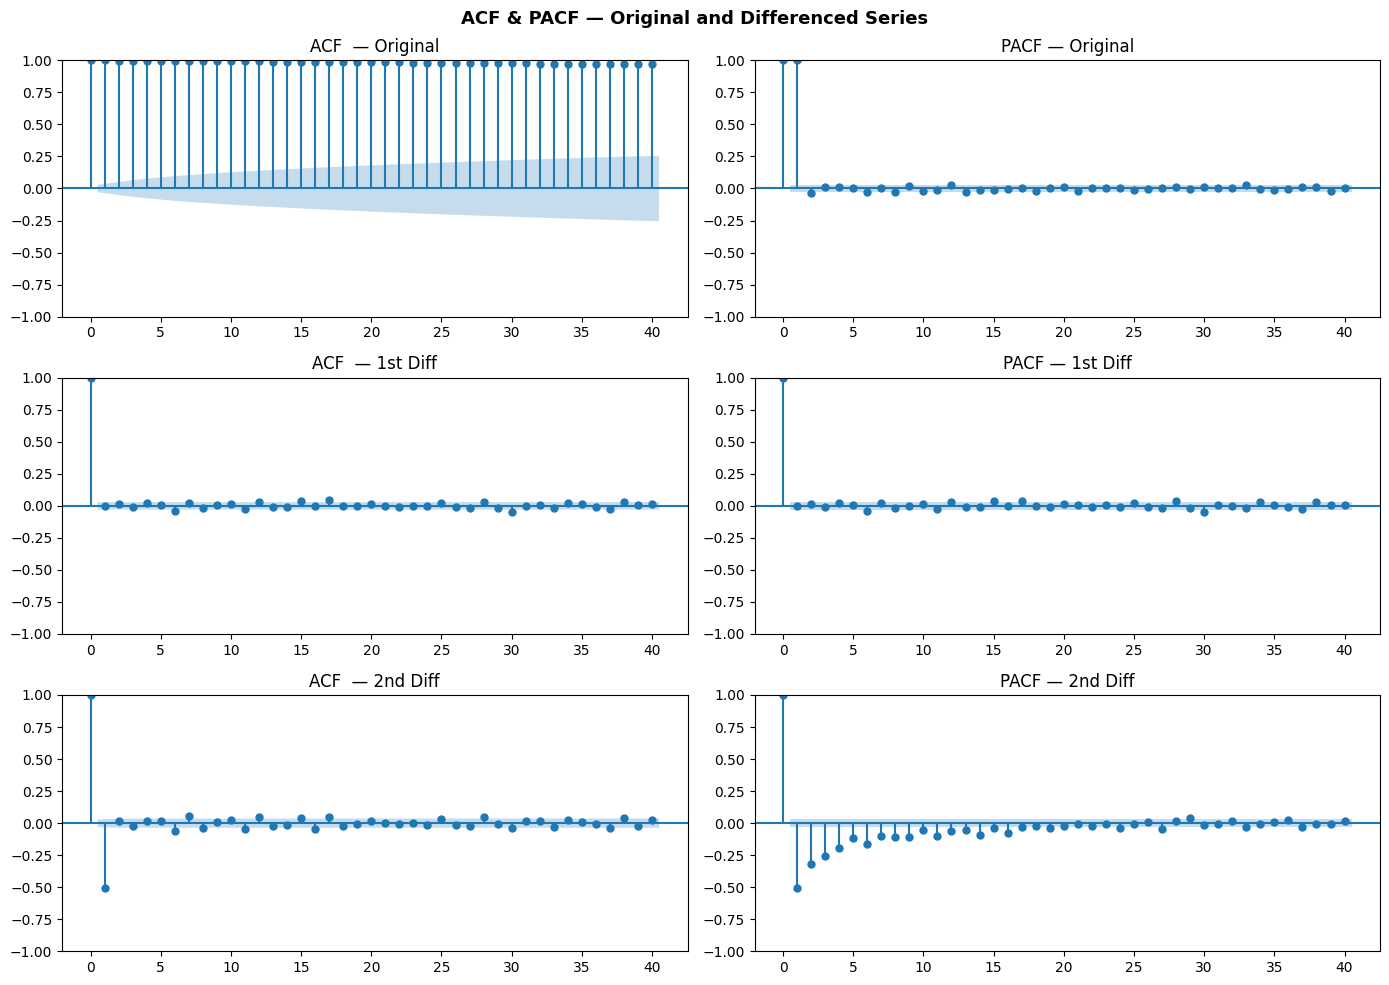

In [12]:
train_d1 = train.diff().dropna()     # 1st difference
train_d2 = train_d1.diff().dropna()  # 2nd difference

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

plot_acf (train,    lags=40, ax=axes[0,0], title='ACF  — Original')
plot_pacf(train,    lags=40, ax=axes[0,1], title='PACF — Original',  method='ywm')
plot_acf (train_d1, lags=40, ax=axes[1,0], title='ACF  — 1st Diff')
plot_pacf(train_d1, lags=40, ax=axes[1,1], title='PACF — 1st Diff',  method='ywm')
plot_acf (train_d2, lags=40, ax=axes[2,0], title='ACF  — 2nd Diff')
plot_pacf(train_d2, lags=40, ax=axes[2,1], title='PACF — 2nd Diff',  method='ywm')

plt.suptitle('ACF & PACF — Original and Differenced Series', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

6(d): Fit Five ARIMA Models

In [13]:
MODELS = {
    'ARIMA(1,1,0)': (1,1,0),
    'ARIMA(0,1,1)': (0,1,1),
    'ARIMA(1,1,1)': (1,1,1),
    'ARIMA(2,1,1)': (2,1,1),
    'ARIMA(1,1,2)': (1,1,2),
}

fitted = {}
for name, order in MODELS.items():
    fitted[name] = ARIMA(train, order=order).fit()
    print(f'{name}  ->  AIC={fitted[name].aic:.2f}  BIC={fitted[name].bic:.2f}')

ARIMA(1,1,0)  ->  AIC=56454.95  BIC=56467.79
ARIMA(0,1,1)  ->  AIC=56454.95  BIC=56467.79
ARIMA(1,1,1)  ->  AIC=56456.75  BIC=56476.01
ARIMA(2,1,1)  ->  AIC=56457.86  BIC=56483.54
ARIMA(1,1,2)  ->  AIC=56458.30  BIC=56483.98


6(e): m-Step Ahead Forecasts (m = 1 … 5)

In [14]:
forecasts = {name: res.get_forecast(steps=5).predicted_mean.values
             for name, res in fitted.items()}

true_vals = test.values

print(f'{"Model":<18} {"m=1":>10} {"m=2":>10} {"m=3":>10} {"m=4":>10} {"m=5":>10}')
print('-'*68)
print(f'{"True Value":<18}' + ''.join(f'{v:>10.2f}' for v in true_vals))
print('-'*68)
for name, fc in forecasts.items():
    print(f'{name:<18}' + ''.join(f'{v:>10.2f}' for v in fc))

Model                     m=1        m=2        m=3        m=4        m=5
--------------------------------------------------------------------
True Value          23114.50  22512.65  22912.40  23306.45  22819.60
--------------------------------------------------------------------
ARIMA(1,1,0)        23001.71  23001.71  23001.71  23001.71  23001.71
ARIMA(0,1,1)        23001.74  23001.74  23001.74  23001.74  23001.74
ARIMA(1,1,1)        23007.27  23004.83  23005.99  23005.44  23005.70
ARIMA(2,1,1)        23004.47  22992.27  22996.95  22994.99  22995.81
ARIMA(1,1,2)        23004.01  22994.98  22994.67  22994.65  22994.65


6(f): RMSE, MAE, R² + Forecast Plots

Model                  RMSE      MAE       R2
----------------------------------------------
ARIMA(1,1,0)         277.82   235.60  -0.0649
ARIMA(0,1,1)         277.82   235.61  -0.0650
ARIMA(1,1,1)         278.47   236.02  -0.0700
ARIMA(2,1,1)         274.72   232.37  -0.0413
ARIMA(1,1,2)         275.49   232.39  -0.0472


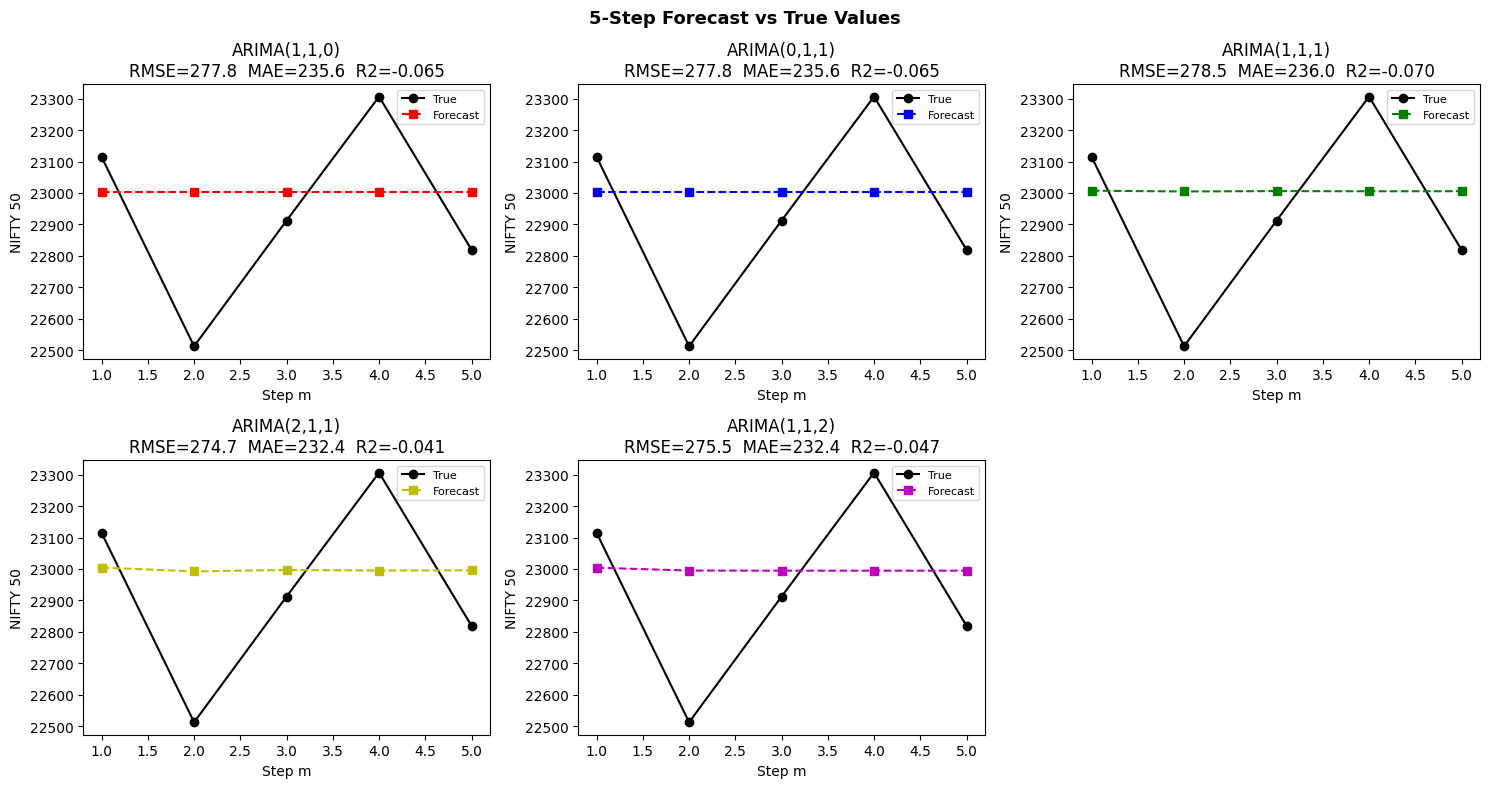

In [15]:
# Metrics
print(f'{"Model":<18} {"RMSE":>8} {"MAE":>8} {"R2":>8}')
print('-'*46)
metrics = {}
for name, fc in forecasts.items():
    rmse = np.sqrt(mean_squared_error(true_vals, fc))
    mae  = mean_absolute_error(true_vals, fc)
    r2   = r2_score(true_vals, fc)
    metrics[name] = (rmse, mae, r2)
    print(f'{name:<18} {rmse:>8.2f} {mae:>8.2f} {r2:>8.4f}')

# Forecast vs True Plot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = ['r','b','g','y','m']
steps  = range(1, 6)

for i, (name, fc) in enumerate(forecasts.items()):
    ax = axes[i]
    ax.plot(steps, true_vals, 'ko-', ms=6, lw=1.5, label='True')
    ax.plot(steps, fc, color=colors[i], marker='s', ls='--', ms=6, lw=1.5, label='Forecast')
    rmse, mae, r2 = metrics[name]
    ax.set_title(f'{name}\nRMSE={rmse:.1f}  MAE={mae:.1f}  R2={r2:.3f}')
    ax.set_xlabel('Step m') 
    ax.set_ylabel('NIFTY 50') 
    ax.legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('5-Step Forecast vs True Values', fontsize=13, fontweight='bold')
plt.tight_layout() 
plt.show()

6(g): AIC & BIC Model Selection

                   AIC       BIC
ARIMA(1,1,0)  56454.95  56467.79
ARIMA(0,1,1)  56454.95  56467.79
ARIMA(1,1,1)  56456.75  56476.01
ARIMA(2,1,1)  56457.86  56483.54
ARIMA(1,1,2)  56458.30  56483.98

Best by AIC: ARIMA(1,1,0)
Best by BIC: ARIMA(1,1,0)


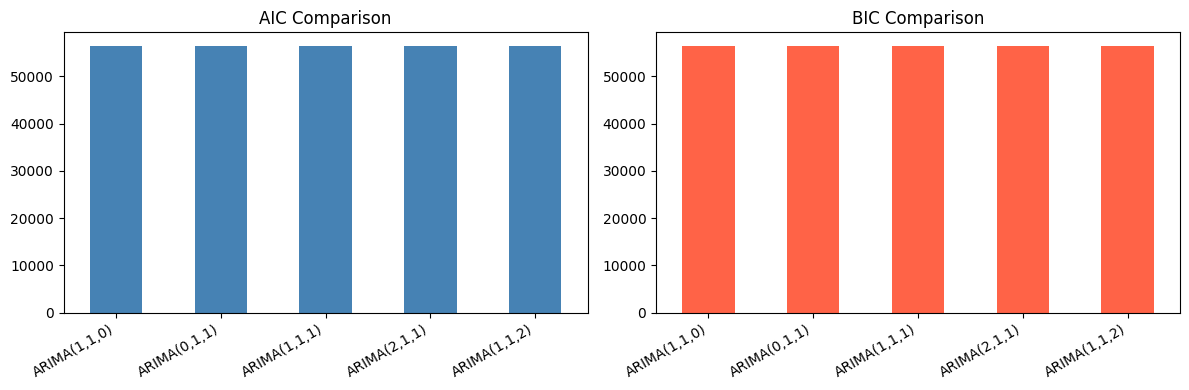

In [16]:
aic_bic = pd.DataFrame(
    {name: {'AIC': res.aic, 'BIC': res.bic} for name, res in fitted.items()}
).T.sort_values('AIC')

print(aic_bic.round(2))
print(f'\nBest by AIC: {aic_bic["AIC"].idxmin()}')
print(f'Best by BIC: {aic_bic["BIC"].idxmin()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
aic_bic['AIC'].plot(kind='bar', ax=axes[0], color='steelblue', title='AIC Comparison')
aic_bic['BIC'].plot(kind='bar', ax=axes[1], color='tomato',    title='BIC Comparison')
for ax in axes: ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout() 
plt.show()